# Notebook 1: Data Preprocessing and Classical Machine Learning

In this notebook, we will use a sports-related dataset from **Hugging Face** to understand how common preprocessing decisions affect a classical machine learning model. --> **"3zden/fbref_football_player_performance_2024-2025"**

The main goal is **not** to build the best possible model. Instead, the goal is to observe how preprocessing choices such as missing value handling, scaling, and dimensionality reduction may change the dataset and the model results.

## Learning objectives

By the end of this notebook, you should be able to:

1. Load a dataset from Hugging Face.
2. Inspect columns, data types, and missing values.
3. Compare deleting missing rows with imputing missing values.
4. Apply feature scaling.
5. Apply PCA for dimensionality reduction.
6. Train a simple machine learning model after different preprocessing strategies.
7. Compare the advantages and disadvantages of each strategy.

## 1. Install and import required libraries

Run the following cell if you are using Google Colab or a fresh environment.

In [1]:
# If needed, uncomment and run this line:
# !pip install datasets pandas numpy scikit-learn matplotlib -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from datasets import load_dataset

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

## 2. Load the dataset from Hugging Face

We will use a football player performance dataset from Hugging Face.

**Task:** Load the dataset and convert it into a Pandas DataFrame.

In [3]:
ds = load_dataset("3zden/fbref_football_player_performance_2024-2025", split="train")
df = ds.to_pandas()

# Display the first rows
display(df.head())

README.md:   0%|          | 0.00/3.73k [00:00<?, ?B/s]

PlayersFBREF.csv:   0%|          | 0.00/312k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2274 [00:00<?, ? examples/s]

,Unnamed: 0,Player,Nation,Position,Age,Matches Played,Starts,Minutes,90s Played,Goals,...,Goals Per 90,Assists Per 90,Goals + Assists Per 90,Non-Penalty Goals Per 90,Non-Penalty Goals + Assists Per 90,xG Per 90,xAG Per 90,xG + xAG Per 90,npxG Per 90,npxG + xAG Per 90
0,0,Mohamed Salah,EGY,AT,32,38,38,"3,371",37.5,29,...,0.77,0.48,1.25,0.53,1.01,0.67,0.38,1.05,0.49,0.87
1,1,Virgil van Dijk,NED,DF,33,37,37,"3,330",37.0,3,...,0.08,0.03,0.11,0.08,0.11,0.06,0.02,0.08,0.06,0.08
2,2,Ryan Gravenberch,NED,MT,22,37,37,"3,160",35.1,0,...,0.00,0.11,0.11,0.00,0.11,0.03,0.09,0.12,0.03,0.12
3,3,Alexis Mac Allister,ARG,MT,25,35,30,"2,599",28.9,5,...,0.17,0.17,0.35,0.17,0.35,0.10,0.16,0.26,0.10,0.26
4,4,Ibrahima Konaté,FRA,DF,25,31,30,"2,560",28.4,1,...,0.04,0.07,0.11,0.04,0.11,0.06,0.03,0.10,0.06,0.10


## 3. Initial data exploration

Before training any model, we need to understand the data.

In this section, inspect:

- the number of rows and columns,
- column names,
- data types,
- summary statistics,
- missing values.

In [4]:
print("Dataset shape:", df.shape)

Dataset shape: (2274, 34)


In [5]:
df.columns.tolist()

['Unnamed: 0',
 'Player',
 'Nation',
 'Position',
 'Age',
 'Matches Played',
 'Starts',
 'Minutes',
 '90s Played',
 'Goals',
 'Assists',
 'Goals + Assists',
 'Non-Penalty Goals',
 'Penalty Goals Made',
 'Penalty Attempts',
 'Yellow Cards',
 'Red Cards',
 'xG',
 'npxG',
 'xAG',
 'npxG + xAG',
 'Progressive Carries',
 'Progressive Passes',
 'Progressive Receives',
 'Goals Per 90',
 'Assists Per 90',
 'Goals + Assists Per 90',
 'Non-Penalty Goals Per 90',
 'Non-Penalty Goals + Assists Per 90',
 'xG Per 90',
 'xAG Per 90',
 'xG + xAG Per 90',
 'npxG Per 90',
 'npxG + xAG Per 90']

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2274 entries, 0 to 2273
Data columns (total 34 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Unnamed: 0                          2274 non-null   int64  
 1   Player                              2274 non-null   object 
 2   Nation                              2274 non-null   object 
 3   Position                            2274 non-null   object 
 4   Age                                 2274 non-null   int64  
 5   Matches Played                      2274 non-null   int64  
 6   Starts                              2274 non-null   int64  
 7   Minutes                             2274 non-null   object 
 8   90s Played                          2274 non-null   float64
 9   Goals                               2274 non-null   int64  
 10  Assists                             2274 non-null   int64  
 11  Goals + Assists                     2274 no

In [7]:
display(df.describe())

,Unnamed: 0,Age,Matches Played,Starts,90s Played,Goals,Assists,Goals + Assists,Non-Penalty Goals,Penalty Goals Made,...,Goals Per 90,Assists Per 90,Goals + Assists Per 90,Non-Penalty Goals Per 90,Non-Penalty Goals + Assists Per 90,xG Per 90,xAG Per 90,xG + xAG Per 90,npxG Per 90,npxG + xAG Per 90
count,2274.000000,2274.000000,2274.000000,2274.000000,2274.000000,2274.000000,2274.000000,2274.000000,2274.000000,2274.000000,...,2274.000000,2274.000000,2274.000000,2274.000000,2274.000000,2274.000000,2274.000000,2274.000000,2274.000000,2274.000000
mean,1136.500000,25.094987,19.226913,14.313105,14.202331,1.566403,1.096746,2.663149,1.434037,0.132366,...,0.096486,0.063602,0.160048,0.089943,0.153514,0.115391,0.075853,0.191042,0.108672,0.184415
std,656.591578,4.465810,11.519163,11.512175,10.968616,3.124944,1.880588,4.497444,2.767307,0.658344,...,0.182532,0.104213,0.234581,0.173435,0.224508,0.185577,0.112750,0.236506,0.177073,0.227744
min,0.000000,15.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,568.250000,22.000000,9.000000,3.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.010000,0.010000,0.040000,0.010000,0.040000
50%,1136.500000,25.000000,20.000000,12.000000,12.300000,0.000000,0.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.060000,0.000000,0.060000,0.050000,0.040000,0.120000,0.050000,0.110000
75%,1704.750000,28.000000,30.000000,25.000000,23.900000,2.000000,1.000000,3.000000,2.000000,0.000000,...,0.120000,0.100000,0.240000,0.110000,0.230000,0.140000,0.110000,0.280000,0.140000,0.260000
max,2273.000000,41.000000,38.000000,38.000000,38.000000,29.000000,18.000000,47.000000,24.000000,9.000000,...,2.430000,1.010000,2.430000,2.430000,2.430000,3.530000,2.470000,3.530000,3.530000,3.530000


In [8]:
missing_values = df.isnull().sum().sort_values(ascending=False)
display(missing_values[missing_values > 0])

,0


## 4. Define a simple machine learning task

We will create a simple classification task.

The target variable will indicate whether a player is an attacking player.

In the original completed notebook, this is created from the `Position` column.

> Educational note: In real machine learning projects, defining the target variable carefully is a critical step. Here, we use a simple target only for demonstration purposes.

In [9]:
df["is_forward"] = df["Position"].astype(str).str.contains("AT").astype(int)

print(df["is_forward"].value_counts())

is_forward
0    1685
1     589
Name: count, dtype: int64


## 5. Select features

We will select a small set of numerical features for the first model.

You may inspect the column names first and then choose the relevant columns.

In [10]:
features = [
    "Age", "Matches Played", "Goals", "Assists", "Yellow Cards",
    "xG", "Progressive Carries", "Progressive Passes"
]

X = df[features]
y = df["is_forward"]

display(X.head())

,Age,Matches Played,Goals,Assists,Yellow Cards,xG,Progressive Carries,Progressive Passes
0,32,38,29,18,1,25.2,154,144
1,33,37,3,1,5,2.2,22,198
2,22,37,0,4,6,1.1,70,181
3,25,35,5,5,6,2.8,36,177
4,25,31,1,2,5,1.7,25,115


## 6. Missing value strategy 1: Delete rows with missing values

The simplest way to handle missing values is to delete rows that contain them.

However, this may remove too much data.

**Task:** Drop missing rows and calculate how much data is lost.

In [11]:
df_selected = df[features + ["is_forward"]].copy()
print("Original number of rows:", len(df_selected))

df_dropped = df_selected.dropna()
print("Rows after dropna:", len(df_dropped))

data_loss = (1 - len(df_dropped) / len(df_selected)) * 100
print("Data loss (%):", round(data_loss, 2))

Original number of rows: 2274
Rows after dropna: 2274
Data loss (%): 0.0


## 7. Train a baseline model after deleting missing rows

Now train a simple Logistic Regression model using the reduced dataset.

In [12]:
X_drop = df_dropped[features]
y_drop = df_dropped["is_forward"]

X_train_drop, X_test_drop, y_train_drop, y_test_drop = train_test_split(
    X_drop, y_drop, test_size=0.2, random_state=42, stratify=y_drop
)

In [13]:
model_drop = LogisticRegression(max_iter=1000)
model_drop.fit(X_train_drop, y_train_drop)

preds_drop = model_drop.predict(X_test_drop)
acc_drop = accuracy_score(y_test_drop, preds_drop)

print("Accuracy after deleting missing rows:", round(acc_drop, 4))

Accuracy after deleting missing rows: 0.8659


## 8. Missing value strategy 2: Fill missing values with imputation

Instead of deleting rows, we can fill missing values.

For numerical columns, common strategies are:

- mean imputation,
- median imputation,
- constant value imputation.

Here, we will use **median imputation** because it is more robust to extreme values than the mean.

In [14]:
df_imputed = df_selected.copy()

imputer = SimpleImputer(strategy="median")
df_imputed[features] = imputer.fit_transform(df_imputed[features])

display(df_imputed.isnull().sum())

,0
Age,0
Matches Played,0
Goals,0
Assists,0
Yellow Cards,0
xG,0
Progressive Carries,0
Progressive Passes,0
is_forward,0


## 9. Train a model after imputation

Now train the same model again, but this time use the dataset where missing values were filled instead of deleted.

In [15]:
X_imp = df_imputed[features]
y_imp = df_imputed["is_forward"]

X_train_imp, X_test_imp, y_train_imp, y_test_imp = train_test_split(
    X_imp, y_imp, test_size=0.2, random_state=42, stratify=y_imp
)

In [16]:
model_imp = LogisticRegression(max_iter=1000)
model_imp.fit(X_train_imp, y_train_imp)

preds_imp = model_imp.predict(X_test_imp)
acc_imp = accuracy_score(y_test_imp, preds_imp)

print("Accuracy after imputation:", round(acc_imp, 4))

Accuracy after imputation: 0.8659


## 10. Feature scaling

Some models perform better when numerical features are on a similar scale.

For example, `Goals`, `Age`, and `Progressive Passes` may have very different numerical ranges.

We will use `StandardScaler`, which transforms features to have approximately mean 0 and standard deviation 1.

In [17]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled = scaler.transform(X_test_imp)

model_scaled = LogisticRegression(max_iter=1000)
model_scaled.fit(X_train_scaled, y_train_imp)

preds_scaled = model_scaled.predict(X_test_scaled)
acc_scaled = accuracy_score(y_test_imp, preds_scaled)

print("Accuracy after imputation + scaling:", round(acc_scaled, 4))

Accuracy after imputation + scaling: 0.8659


## 11. Dimensionality reduction with PCA

PCA reduces the number of features by creating new components that summarize the original features.

This can reduce complexity, but it may also remove useful information.

**Important:** PCA should be applied after scaling.

In [18]:
pca = PCA(n_components=3)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

model_pca = LogisticRegression(max_iter=1000)
model_pca.fit(X_train_pca, y_train_imp)

preds_pca = model_pca.predict(X_test_pca)
acc_pca = accuracy_score(y_test_imp, preds_pca)

print("Accuracy after imputation + scaling + PCA:", round(acc_pca, 4))

Accuracy after imputation + scaling + PCA: 0.844


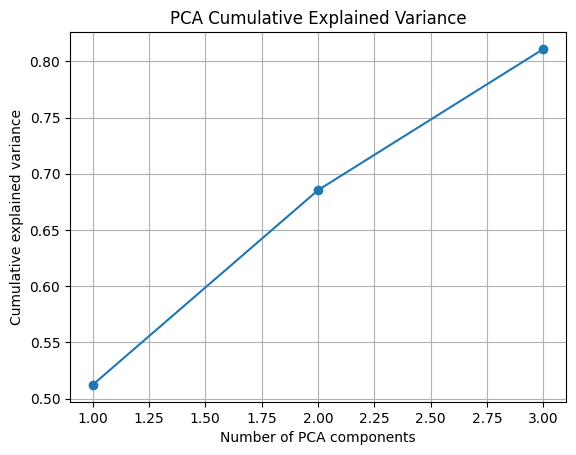

In [19]:
explained_variance = np.cumsum(pca.explained_variance_ratio_)

plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker="o")
plt.xlabel("Number of PCA components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA Cumulative Explained Variance")
plt.grid(True)
plt.show()

## 12. Try different numbers of PCA components

In this activity, test PCA with different numbers of components and compare the accuracy values.

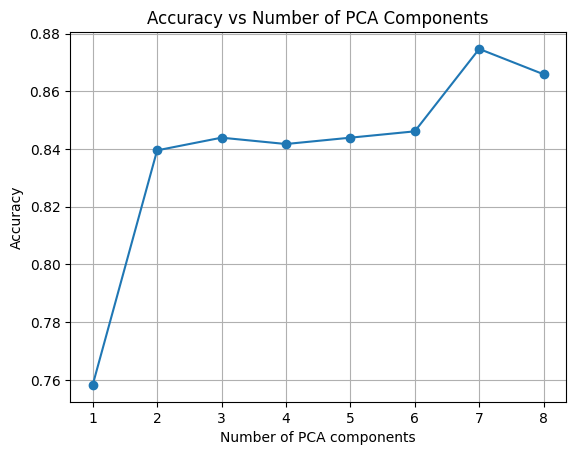

In [20]:
accuracies = []
n_features = len(features)

for n in range(1, n_features + 1):
    pca_temp = PCA(n_components=n)
    X_train_pca_temp = pca_temp.fit_transform(X_train_scaled)
    X_test_pca_temp = pca_temp.transform(X_test_scaled)

    model_temp = LogisticRegression(max_iter=1000)
    model_temp.fit(X_train_pca_temp, y_train_imp)

    pred_temp = model_temp.predict(X_test_pca_temp)
    acc_temp = accuracy_score(y_test_imp, pred_temp)

    accuracies.append(acc_temp)

plt.plot(range(1, n_features + 1), accuracies, marker="o")
plt.xlabel("Number of PCA components")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Number of PCA Components")
plt.grid(True)
plt.show()

## 13. Compare all results

Finally, summarize the model results in a single table.

In [22]:
best_pca_accuracy = max(accuracies)
optimal_n_components = accuracies.index(best_pca_accuracy) + 1

results = pd.DataFrame({
    "Experiment": [
        "Delete missing rows",
        "Imputation",
        "Imputation + scaling",
        "Imputation + scaling + PCA (n=3)",
        f"Imputation + scaling + PCA (n={optimal_n_components}, best)"
    ],
    "Accuracy": [
        acc_drop,
        acc_imp,
        acc_scaled,
        acc_pca,
        best_pca_accuracy
    ]
})

display(results)

,Experiment,Accuracy
0,Delete missing rows,0.865934
1,Imputation,0.865934
2,Imputation + scaling,0.865934
3,Imputation + scaling + PCA (n=3),0.843956
4,"Imputation + scaling + PCA (n=7, best)",0.874725


## 14. Reflection questions

Answer the following questions after completing the notebook:

1. How much data was lost when missing rows were deleted?
2. Did imputation improve or reduce the model score?
3. Did scaling change the model score?
4. Did PCA improve or reduce the model score?
5. Why is preprocessing not always guaranteed to improve performance?
6. Which preprocessing strategy would you choose for this dataset, and why?